In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime

In [2]:
### 讀取資料 ###
# df = pd.read_csv("/Users/dimplechang/Desktop/Kaggle Practice/Medical Appointment No Shows/KaggleV2-May-2016.csv")
df = pd.read_csv("KaggleV2-May-2016.csv")

# 理解資料

In [3]:
print(df.head())

      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0        0      

In [4]:
print(df.info()) # 看看有沒有缺失值

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB
None


In [5]:
print(df.describe())

          PatientId  AppointmentID            Age    Scholarship  \
count  1.105270e+05   1.105270e+05  110527.000000  110527.000000   
mean   1.474963e+14   5.675305e+06      37.088874       0.098266   
std    2.560949e+14   7.129575e+04      23.110205       0.297675   
min    3.921784e+04   5.030230e+06      -1.000000       0.000000   
25%    4.172614e+12   5.640286e+06      18.000000       0.000000   
50%    3.173184e+13   5.680573e+06      37.000000       0.000000   
75%    9.439172e+13   5.725524e+06      55.000000       0.000000   
max    9.999816e+14   5.790484e+06     115.000000       1.000000   

        Hipertension       Diabetes     Alcoholism        Handcap  \
count  110527.000000  110527.000000  110527.000000  110527.000000   
mean        0.197246       0.071865       0.030400       0.022248   
std         0.397921       0.258265       0.171686       0.161543   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       

# 處理資料 #

### 1. 刪除不必要的 ID 欄位

In [6]:
df = df.drop("AppointmentID", axis=1)
df.head()

,PatientId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


### 2. 年齡資料
##### 2-1. 偵測到年齡為 -1 之異常值，判定為系統登錄錯誤。考量樣本數充足（N > 110,000），為確保後續統計分析之精確性，採取刪除處理

In [7]:
df = df[df["Age"]>0]

### 3. 疾病資料
##### 3-1. 新增一欄「慢性疾病總數」："Hipertension", "Diabetes", "Alcoholism"

In [8]:
df["Comorbidity"] = df["Hipertension"] + df["Diabetes"] + df["Alcoholism"]

### 4. 日期時間資料
##### 4-1. 把 ScheduleDay 和 AppointmentDay 轉換格式

* 先轉換成 datetime 格式之後才可以運算
* 只選出日期的部分「年月日」，時間不需要 > 使用 dt.normalize() 

In [9]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"]).dt.normalize() # 如果使用 dt.date，資料型態會變轉成物件 object，之後做運算可能會有問題
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"]).dt.normalize()

##### 4-2. 新增一欄為 WaitingDays: 計算出提前預約天數

In [10]:
df["WaitingDays"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days # 如果沒有加 dt.days 他會是 datetime 格式，後續不好做運算

# 檢查是否有異常值，WaitingDays 照理說應該都要 >=0
# print(df[df["WaitingDays"] < 0].shape[0]) # shape可以知道符合條件的資料有幾筆，shape[0] 表示列數，shape[1] 表示欄數 

# 有五筆資料的 WaitingDays < 0，因資料量夠大，直接刪除這些異常值，以避免後續統計出問題
df = df[df["WaitingDays"]>=0]
# print(df[df["WaitingDays"] < 0].shape[0]) #再次確認數據

# 了解整體 WaitingDays 數據
print(df["WaitingDays"].describe())

count    106982.000000
mean         10.167290
std          15.263631
min           0.000000
25%           0.000000
50%           4.000000
75%          14.000000
max         179.000000
Name: WaitingDays, dtype: float64


### 5. 將性別 Gender 轉換為 one-hot encoding

In [11]:
df_gender = pd.get_dummies(df.Gender, dtype=int)
df= pd.concat([df_gender, df], axis=1)
print(df.head())

   F  M     PatientId Gender              ScheduledDay  \
0  1  0  2.987250e+13      F 2016-04-29 00:00:00+00:00   
1  0  1  5.589978e+14      M 2016-04-29 00:00:00+00:00   
2  1  0  4.262962e+12      F 2016-04-29 00:00:00+00:00   
3  1  0  8.679512e+11      F 2016-04-29 00:00:00+00:00   
4  1  0  8.841186e+12      F 2016-04-29 00:00:00+00:00   

             AppointmentDay  Age      Neighbourhood  Scholarship  \
0 2016-04-29 00:00:00+00:00   62    JARDIM DA PENHA            0   
1 2016-04-29 00:00:00+00:00   56    JARDIM DA PENHA            0   
2 2016-04-29 00:00:00+00:00   62      MATA DA PRAIA            0   
3 2016-04-29 00:00:00+00:00    8  PONTAL DE CAMBURI            0   
4 2016-04-29 00:00:00+00:00   56    JARDIM DA PENHA            0   

   Hipertension  Diabetes  Alcoholism  Handcap  SMS_received No-show  \
0             1         0           0        0             0      No   
1             0         0           0        0             0      No   
2             0         0 

### 6. No-Show 資料：把資料中的 Yes/No，轉換成 1/0

In [12]:
df["No_show_binary"] = df["No-show"].map({"Yes":1, "No":0}) 

### EDA 前再次了解資料 

In [13]:
print(df.head())

   F  M     PatientId Gender              ScheduledDay  \
0  1  0  2.987250e+13      F 2016-04-29 00:00:00+00:00   
1  0  1  5.589978e+14      M 2016-04-29 00:00:00+00:00   
2  1  0  4.262962e+12      F 2016-04-29 00:00:00+00:00   
3  1  0  8.679512e+11      F 2016-04-29 00:00:00+00:00   
4  1  0  8.841186e+12      F 2016-04-29 00:00:00+00:00   

             AppointmentDay  Age      Neighbourhood  Scholarship  \
0 2016-04-29 00:00:00+00:00   62    JARDIM DA PENHA            0   
1 2016-04-29 00:00:00+00:00   56    JARDIM DA PENHA            0   
2 2016-04-29 00:00:00+00:00   62      MATA DA PRAIA            0   
3 2016-04-29 00:00:00+00:00    8  PONTAL DE CAMBURI            0   
4 2016-04-29 00:00:00+00:00   56    JARDIM DA PENHA            0   

   Hipertension  Diabetes  Alcoholism  Handcap  SMS_received No-show  \
0             1         0           0        0             0      No   
1             0         0           0        0             0      No   
2             0         0 

In [14]:
print(df.describe())

                   F              M     PatientId            Age  \
count  106982.000000  106982.000000  1.069820e+05  106982.000000   
mean        0.655391       0.344609  1.472785e+14      38.316315   
std         0.475243       0.475243  2.558181e+14      22.466023   
min         0.000000       0.000000  3.921784e+04       1.000000   
25%         0.000000       0.000000  4.173345e+12      19.000000   
50%         1.000000       0.000000  3.172598e+13      38.000000   
75%         1.000000       1.000000  9.433627e+13      56.000000   
max         1.000000       1.000000  9.999816e+14     115.000000   

         Scholarship   Hipertension       Diabetes     Alcoholism  \
count  106982.000000  106982.000000  106982.000000  106982.000000   
mean        0.101036       0.203782       0.074246       0.031407   
std         0.301377       0.402811       0.262172       0.174416   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       

# Exploratory Data Analysis (EDA) #
## No-show Analysis

#### 1. 整體爽約比例

In [15]:
percentage = df["No_show_binary"].mean() * 100
print("爽約比例：%.2f%%"%percentage)

爽約比例：20.26%


#### 2. 爽約 與「性別」有關嗎？

2-1 男女各自的「履約人數」與「爽約人數」

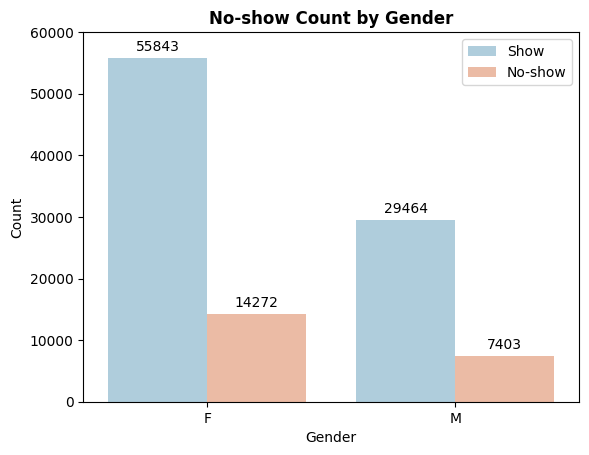

In [16]:
ax = sns.countplot(
    x='Gender', 
    hue='No-show', 
    data=df, 
    palette='RdBu_r'
)

# 在柱狀圖上方顯示實際人數
# 用 for 迴圈到所有 containers，確保每一根柱子都有數字標籤
for container in ax.containers:
    ax.bar_label(container, fmt = "%d", padding=3)

plt.title('No-show Count by Gender', fontweight='bold')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['F', 'M']) 
plt.legend(labels=['Show', 'No-show'])
plt.ylim(0, 60000)
plt.show()

2-2 男女各自的「平均爽約率」

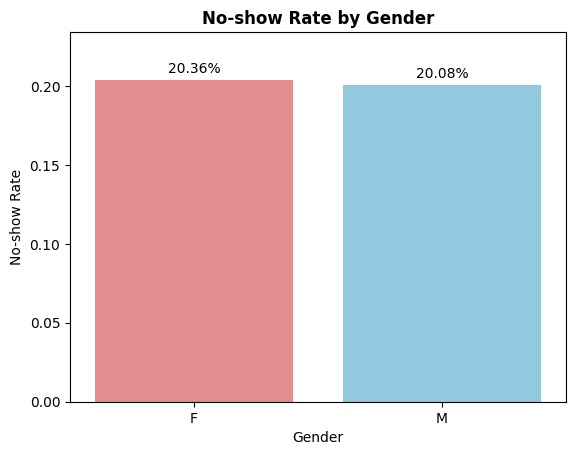

In [17]:
# 繪圖並將回傳的容器存入變數 ax
# barplot 預設會計算 y 軸的平均值，因為 No-show 是 0 和 1，其平均值就等於「爽約率」
ax2 = sns.barplot(
    x = "Gender",
    y = "No_show_binary",   
    data = df,
    palette = ["lightcoral", "skyblue"],
    hue = "Gender",
    legend = False,   # 隱藏圖例讓畫面更乾淨
    errorbar=None     # 不顯示誤差線
)

# 使用 bar_label 自動標註數值
for container in ax2.containers:
    # c 是 Matplotlib 裡的「長條（Rectangle）物件」
    # .get_height() 是這個物件內建的方法，用來取出這個長條的『高度數值』
    percentage_labels = [f'{c.get_height() * 100:.2f}%' for c in container]
    ax2.bar_label(container, labels=percentage_labels, padding=3)   # padding 是數值與長條頂端的距離


plt.ylabel("No-show Rate")
plt.title("No-show Rate by Gender", fontweight='bold')
plt.ylim(0, df.groupby("Gender")["No_show_binary"].mean().max() * 1.15) # 稍微拉高 y 軸避免文字被頂掉
plt.show()

小結：從上面的兩張圖表可以看出：
* 單從男女人數來看，女性掛號人數較多、爽約人數也叫多，但若以男女性各自「爽約機率」來看是差不多的
* 雖然女性看診行為更活躍，但性別本身並不是很大的影響病患爽約的機率。
  機器學習模型在後續的特徵重要度中，**性別的權重應當不高，應該把目光投向其他更有影響力的特徵**

#### 3. 爽約 與「waiting days」有關嗎？

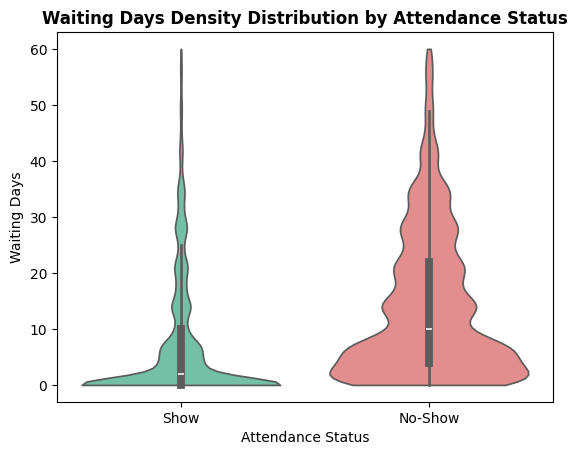

In [18]:
## 專注看 waiting days 在 60 天內的
ax3 = sns.violinplot(
    data = df[df["WaitingDays"]<=60],
    x = "No_show_binary",
    y = "WaitingDays",
    hue = "No_show_binary",
    palette=['mediumaquamarine', 'lightcoral'],
    legend= False,
    cut = 0
)
plt.title('Waiting Days Density Distribution by Attendance Status', fontweight='bold')
plt.ylabel("Waiting Days")
plt.xlabel("Attendance Status")
plt.xticks(ticks=[0, 1], labels=['Show', 'No-Show']) 
plt.show()

小結：
* 小提琴中央的黑底白點，這代表兩組數據的中位數（Median）。可以非常直觀地發現：<br>
  履約組（Show）的等待天數中位數非常低，只有大約 2 到 3 天<br>
  爽約組（No-show）的中位數則顯著拉高，達到了將近 10 天<br>
  --> 等得越久，越容易放鴿子

* 小提琴的胖瘦（密度分佈）<br>
  履約組（Show）呈現一個非常極端的『胖底葫蘆形』。它在 0 天的地方有巨大的膨脹，這代表當天預約當天就診的患者佔了絕大多數，而且這群人的履約率極高。相較之下，爽約組（No-show）整體形狀要寬大許多，甚至在 10 天、20 天、甚至 30 天處都維持著很高的厚度

* **等待天數將會是後續預測模型中，非常核心且關鍵的連續型特徵**

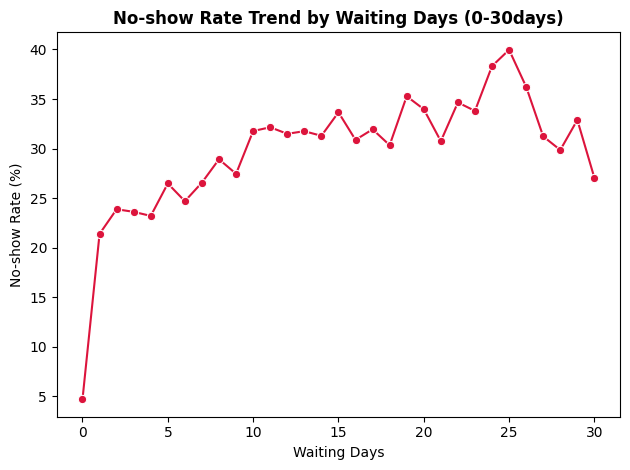

In [19]:
## 計算每個等待天數點的平均爽約率
df_noshow = df[df['WaitingDays'] <= 30].groupby('WaitingDays')['No_show_binary'].mean().reset_index()
# Pandas 算完平均後，會吐出一個叫做 Series 的單欄資料，如果不加 index 那麼資料會誤以為 waitingDays 成 index ><
# reset_index()：會把被塞進索引（Index）的 WaitingDays 撈出來，重新變成一個可以讓 Seaborn 讀取到的欄位
df_noshow['No_show_binary'] = df_noshow['No_show_binary'] * 100 # 轉換成百分比

ax4 = sns.lineplot(
    data = df_noshow,
    x = "WaitingDays",
    y = "No_show_binary", 
    marker = "o",
    lw = 1.5,
    c = "crimson"
)

plt.title('No-show Rate Trend by Waiting Days (0-30days)', fontweight='bold')
plt.xlabel('Waiting Days')
plt.ylabel('No-show Rate (%)')

plt.tight_layout()
plt.show()

小結：
* 當天就診的爽約率極低
* 只要等待天數超過 1 天，爽約率就會迎來爆發性成長，並在 10天 左右超過 30%！

#### 4. 爽約 與「waiting duration x SMS_received」有關嗎？

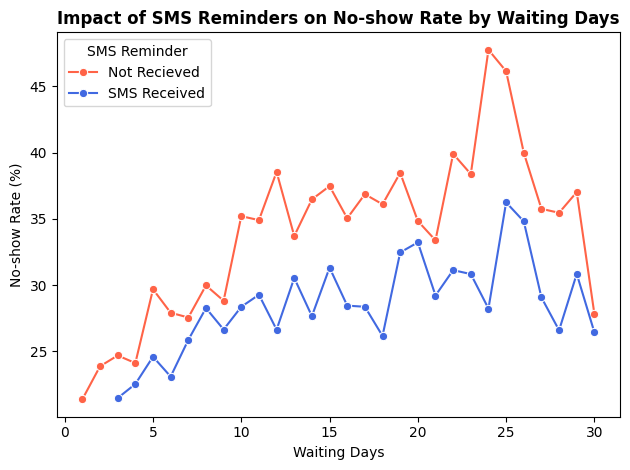

In [20]:
# 篩選出等待天數在 1~30 天之間的資料（排除0天，因為0天不會有簡訊）
df_sms = df[(df["WaitingDays"] >= 1) & (df["WaitingDays"] <= 30)]

df_noshow_sms = df_sms.groupby(["WaitingDays", "SMS_received"])["No_show_binary"].mean().reset_index()
df_noshow_sms["No_show_binary"] = df_noshow_sms["No_show_binary"] * 100 
df_noshow_sms["SMS_received"] = df_noshow_sms["SMS_received"].map({0: "Not Recieved", 1: "SMS Received"})

ax5 = sns.lineplot(
    data = df_noshow_sms,
    x = "WaitingDays",
    y = "No_show_binary", 
    hue = "SMS_received",
    marker = "o",
    lw = 1.5,
    palette={"Not Recieved": "tomato", "SMS Received": "royalblue"}
)
plt.legend(title="SMS Reminder")
plt.xlabel('Waiting Days')
plt.ylabel('No-show Rate (%)')
plt.title("Impact of SMS Reminders on No-show Rate by Waiting Days", fontweight='bold')
plt.tight_layout()
plt.show()

小結：
* 有收到回診訊息的爽約率明顯下降許多

#### 5. 爽約 與「共病數量」有關嗎？ 

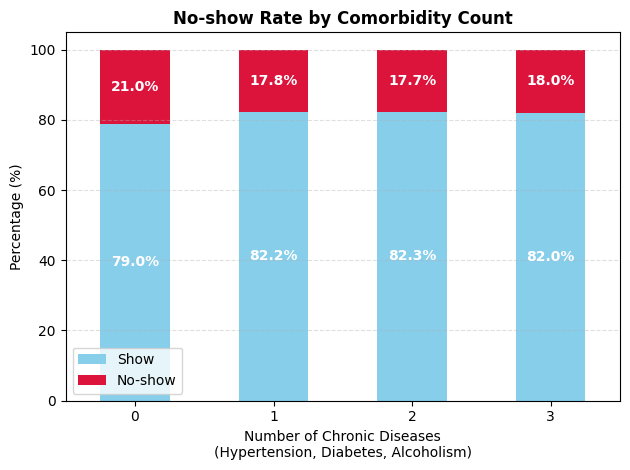

In [21]:
# 1. 建立交叉表並計算百分比
comorbidity_pct = pd.crosstab(df['Comorbidity'], df['No_show_binary'], normalize='index') * 100

# 2. 畫出百分比堆疊圖
ax6 = comorbidity_pct.plot(
    kind='bar', 
    stacked=True,
    color = ["skyblue", "crimson"]
)

for container in ax6.containers:
    # label_type='center' 會把文字置中在每個顏色的方塊內
    ax6.bar_label(container, label_type='center', fmt='%.1f%%', color='white', fontweight="bold")

plt.title('No-show Rate by Comorbidity Count', fontweight='bold')
plt.xlabel('Number of Chronic Diseases\n(Hypertension, Diabetes, Alcoholism)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(labels=['Show', 'No-show'], loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#### 6. 爽約 與「身障」有關嗎？ 

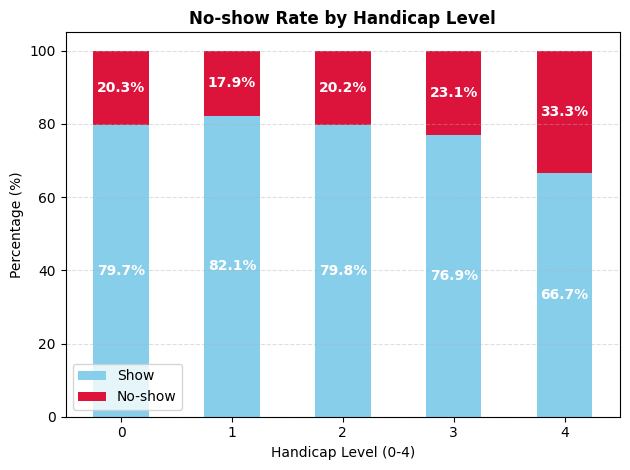

In [22]:
handicap_pct = pd.crosstab(df['Handcap'], df['No_show_binary'], normalize='index') * 100

ax7 = handicap_pct.plot(kind='bar', stacked=True, color = ["skyblue", "crimson"])

for container in ax7.containers:
    ax7.bar_label(container, label_type='center', fmt='%.1f%%', color='white', fontweight="bold")

plt.title('No-show Rate by Handicap Level', fontweight='bold')
plt.xlabel('Handicap Level (0-4)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(labels=['Show', 'No-show'], loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#### 7. 爽約 與「福利補助 Scholarship」有關嗎？ 

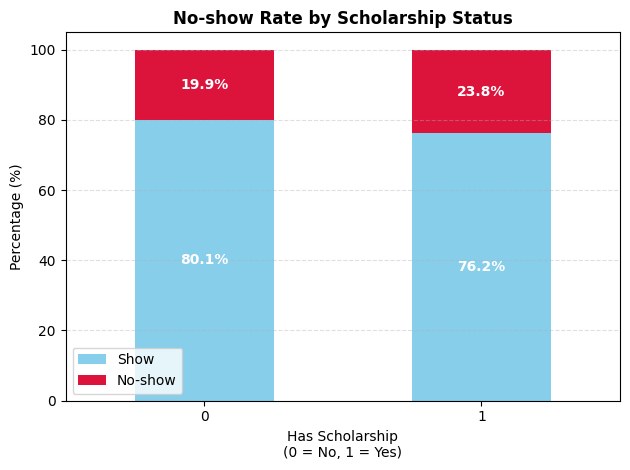

In [23]:
scholar_pct = pd.crosstab(df['Scholarship'], df['No_show_binary'], normalize='index') * 100

ax8 = scholar_pct.plot(kind='bar', stacked=True, color = ["skyblue", "crimson"])

for container in ax8.containers:
    ax8.bar_label(container, label_type='center', fmt='%.1f%%', color='white', fontweight="bold")

plt.title('No-show Rate by Scholarship Status', fontweight='bold')
plt.xlabel('Has Scholarship\n(0 = No, 1 = Yes)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(labels=['Show', 'No-show'], loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#### 8. 是否有「同個病人」重複看診？

8-1 總資料筆數 vs 病人數（同個 ID 算同一個人）

In [24]:
print("Total Records:", len(df.PatientId))
print("Unique Patients:", len(df.PatientId.unique()))

Total Records: 106982
Unique Patients: 60270


8-2 常客爽約率

In [25]:
patient_behavior = df.groupby("PatientId").aggregate(
    total_appointment= ("No_show_binary", "count"),
    noshow_rate = ("No_show_binary", "mean")
).reset_index()

patient_behavior['noshow_rate'] = patient_behavior['noshow_rate'] * 100

In [26]:
# 篩選出常客：appointment >=3
regular = patient_behavior[patient_behavior["total_appointment"]>=3]
regular.describe()

,PatientId,total_appointment,noshow_rate
count,1.011900e+04,10119.000000,10119.000000
mean,1.475933e+14,4.301808,21.558315
std,2.567516e+14,3.233275,24.864980
min,1.889645e+08,3.000000,0.000000
25%,4.167614e+12,3.000000,0.000000
50%,3.132849e+13,3.000000,16.666667
75%,9.396288e+13,5.000000,33.333333
max,9.999320e+14,88.000000,100.000000


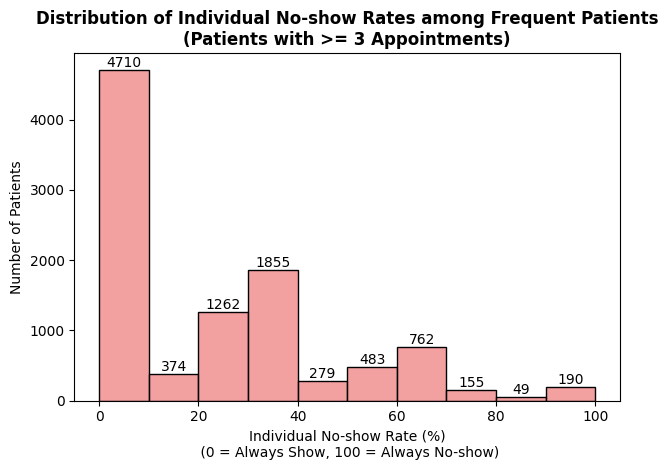

In [27]:
# 畫出常客（掛號 >= 3次）的爽約率分佈
ax9 = sns.histplot(
    data=regular, 
    x='noshow_rate', 
    bins=10, 
    kde=False, 
    color='lightcoral'
)

for container in ax9.containers:
    ax9.bar_label(container)


plt.title('Distribution of Individual No-show Rates among Frequent Patients\n(Patients with >= 3 Appointments)', fontweight='bold')
plt.xlabel('Individual No-show Rate (%)\n (0 = Always Show, 100 = Always No-show)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

小結：
* 在 0% 看到一根特別長的柱（代表這群常客大部分都超級乖）
* 病人的習慣具有高度一致性

#### 9. 爽約 與 Neighborhood 有關嗎？

In [28]:
neighbor = df.groupby("Neighbourhood").aggregate(noshow_rate = ("No_show_binary", "mean")).reset_index()
neighbor["noshow_rate"] = neighbor["noshow_rate"] * 100

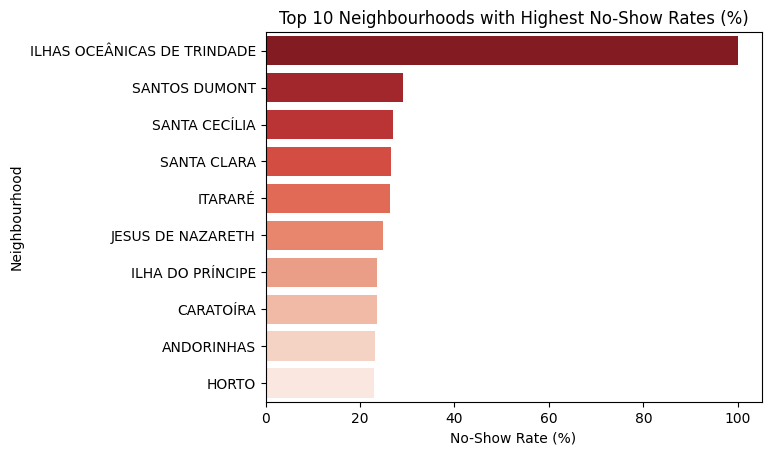

In [29]:
neighbor_sorted = neighbor.sort_values(by="noshow_rate", ascending=False)

# 畫出爽約率最高的 Top 10 地區
sns.barplot(
    x="noshow_rate", 
    y="Neighbourhood", 
    data=neighbor_sorted.head(10), 
    hue = "Neighbourhood",
    palette="Reds_r"
)

plt.title("Top 10 Neighbourhoods with Highest No-Show Rates (%)")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Neighbourhood")
plt.show()

# 特徵(features)選擇 & 區分特徵與目標(target)

In [30]:
df.head()

,F,M,PatientId,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,Comorbidity,WaitingDays,No_show_binary
0,1,0,2.987250e+13,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,1,0,0
1,0,1,5.589978e+14,M,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,0,0
2,1,0,4.262962e+12,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,0,0
3,1,0,8.679512e+11,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,0,0
4,1,0,8.841186e+12,F,2016-04-29 00:00:00+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,2,0,0


In [31]:
X = df.drop(columns=[
    "PatientId", "F", "M","Gender", 
    "ScheduledDay", "AppointmentDay", "No-show", "No_show_binary",
    "Hipertension", "Diabetes", "Alcoholism"
])
y = df["No_show_binary"]
X.head()

,Age,Neighbourhood,Scholarship,Handcap,SMS_received,Comorbidity,WaitingDays
0,62,JARDIM DA PENHA,0,0,0,1,0
1,56,JARDIM DA PENHA,0,0,0,0,0
2,62,MATA DA PRAIA,0,0,0,0,0
3,8,PONTAL DE CAMBURI,0,0,0,0,0
4,56,JARDIM DA PENHA,0,0,0,2,0


In [32]:
X.describe()

,Age,Scholarship,Handcap,SMS_received,Comorbidity,WaitingDays
count,106982.000000,106982.000000,106982.000000,106982.000000,106982.000000,106982.000000
mean,38.316315,0.101036,0.022957,0.323279,0.309435,10.167290
std,22.466023,0.301377,0.164064,0.467730,0.604944,15.263631
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,56.000000,0.000000,0.000000,1.000000,0.000000,14.000000
max,115.000000,1.000000,4.000000,1.000000,3.000000,179.000000


# 切分資料集

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y  # 因為 No-show 的人偏少，依據 y 的比例分層切分，解決樣本不平衡問題，確保模型評估公平性
                                                   )

### 針對 Neighborhood 做處理

In [34]:
# 1. 建立一個臨時的 DataFrame，把地區和答案綁在一起
temp_df = pd.DataFrame({
    'Neighbourhood': X_train['Neighbourhood'],
    'No_show': y_train
})

# 2. 用這個臨時的 DataFrame 來做 groupby 算平均
neighbor = temp_df.groupby("Neighbourhood").aggregate(noshow_rate=("No_show", "mean")).reset_index()
neighbor

,Neighbourhood,noshow_rate
0,AEROPORTO,0.166667
1,ANDORINHAS,0.234723
2,ANTÔNIO HONÓRIO,0.161765
3,ARIOVALDO FAVALESSA,0.219626
4,BARRO VERMELHO,0.202492
...,...,...
76,SÃO JOSÉ,0.211513
77,SÃO PEDRO,0.211991
78,TABUAZEIRO,0.186533
79,UNIVERSITÁRIO,0.217742


In [35]:
# 合併回訓練集
X_train = X_train.merge(neighbor, on="Neighbourhood", how="left")
X_train.rename(columns={"noshow_rate": "Neighbourhood_risk"}, inplace=True) # 改名

# 合併回測試集（用【訓練集算出來的 neighbor】來對應！）
X_test = X_test.merge(neighbor, on="Neighbourhood", how="left")
X_test.rename(columns={"noshow_rate": "Neighbourhood_risk"}, inplace=True)

# 如果測試集有出現訓練集沒看過的地區，補上訓練集的整體平均爽約率20.26%
X_test["Neighbourhood_risk"] = X_test["Neighbourhood_risk"].fillna(0.2026)

# 最後把原本的文字欄位 "Neighbourhood" 從 X_train 和 X_test 中 drop 掉
X_train.drop(columns=["Neighbourhood"], inplace=True)
X_test.drop(columns=["Neighbourhood"], inplace=True)

# 標準化 StandardScaler

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 針對「Age」、「WaitingDays」做標準化
X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std[["Age", "WaitingDays"]] = scaler.fit_transform(X_train[["Age", "WaitingDays"]])
X_test_std[["Age", "WaitingDays"]] = scaler.transform(X_test[["Age", "WaitingDays"]])
X_train_std

,Age,Scholarship,Handcap,SMS_received,Comorbidity,WaitingDays,Neighbourhood_risk
0,-0.726654,0,0,1,0,0.250640,0.225426
1,1.674715,0,0,0,1,-0.665793,0.186533
2,-0.593245,1,0,0,0,-0.665793,0.199175
3,-1.616050,1,1,0,0,0.708856,0.173627
4,0.073802,0,0,0,0,-0.665793,0.186724
...,...,...,...,...,...,...,...
85580,-1.082413,0,0,1,0,0.185180,0.186724
85581,-1.660520,0,0,1,0,1.101613,0.189524
85582,-0.370896,0,0,1,0,0.250640,0.222937
85583,0.785319,0,0,1,1,2.410804,0.205451


# 建模

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, RocCurveDisplay, roc_auc_score, roc_curve

### 1 -  Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression

logr = LogisticRegression(random_state=42, max_iter=1000)
logr.fit(X_train_std, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
logr_pred_train = logr.predict(X_train_std)  
logr_pred_test = logr.predict(X_test_std)    

In [40]:
print(f"LR Train Accuracy: {accuracy_score(y_train, logr_pred_train):.5f}")  
print(f"LR Test Accuracy: {accuracy_score(y_test, logr_pred_test):.5f}")    

LR Train Accuracy: 0.79449
LR Test Accuracy: 0.79530


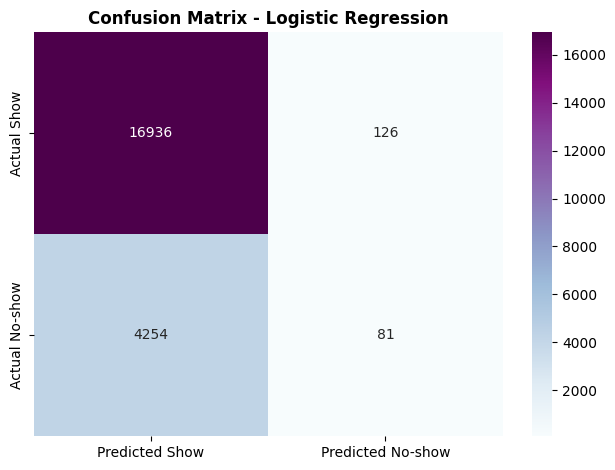

In [41]:
cm_LR = confusion_matrix(y_test, logr_pred_test)
sns.heatmap(cm_LR, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=['Predicted Show', 'Predicted No-show'],
            yticklabels=['Actual Show', 'Actual No-show'])
plt.title('Confusion Matrix - Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
print(classification_report(y_test, logr_pred_test))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89     17062
           1       0.39      0.02      0.04      4335

    accuracy                           0.80     21397
   macro avg       0.60      0.51      0.46     21397
weighted avg       0.72      0.80      0.71     21397



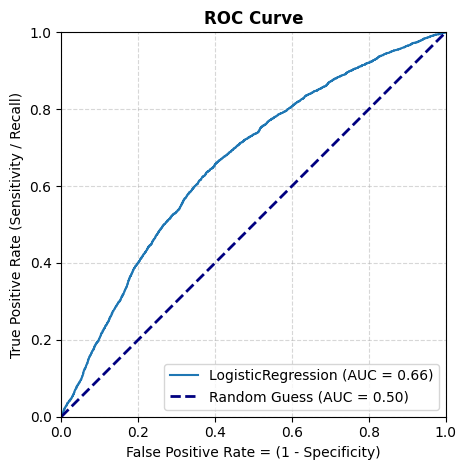

In [43]:
LR_disp = RocCurveDisplay.from_estimator(logr, X_test_std, y_test)

# 繪製對角盲猜基準線（此時會乖乖畫在同一張圖上）
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess (AUC = 0.50)") 

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate = (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

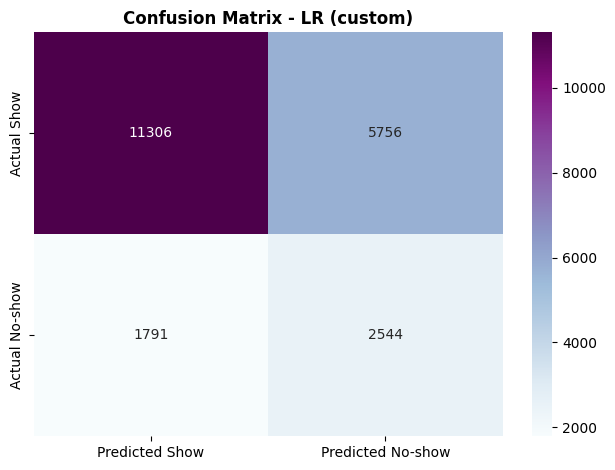

In [77]:
logr_pred_test_proba = logr.predict_proba(X_test_std)[:, 1] 

custom_threshold = 0.2
logr_pred_custom = (logr_pred_test_proba >= custom_threshold).astype(int)

cm_logr_custom = confusion_matrix(y_test, logr_pred_custom)
sns.heatmap(cm_logr_custom, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=['Predicted Show', 'Predicted No-show'],
            yticklabels=['Actual Show', 'Actual No-show'])
plt.title('Confusion Matrix - LR (custom)', fontweight='bold')
plt.tight_layout()
plt.show()

In [78]:
print(classification_report(y_test, logr_pred_custom))

              precision    recall  f1-score   support

           0       0.86      0.66      0.75     17062
           1       0.31      0.59      0.40      4335

    accuracy                           0.65     21397
   macro avg       0.58      0.62      0.58     21397
weighted avg       0.75      0.65      0.68     21397



### 2 - K Nearest Neighborhood (KNN)

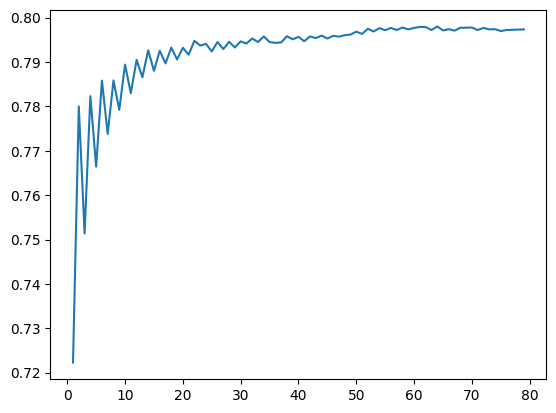

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

accuracy = []

for k in range(1, 80):
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1) 
    knn.fit(X_train_std, y_train)
    y_pred = knn.predict(X_test_std)              
    accuracy.append(metrics.accuracy_score(y_test, y_pred)) 

k_range = range(1,80)
plt.plot(k_range, accuracy)
plt.show()

In [45]:
# 1. 找出 accuracy 列表中的最大值
max_accuracy = max(accuracy)

# 2. 找出這個最大值在列表中的位置（index），記得要 +1 才是真正的 K 值
# 因為 range(1, 100) 的第一個元素 accuracy[0] 對應的是 k=1
best_k = accuracy.index(max_accuracy) + 1

print(f"最高準確度為: {max_accuracy:.4f}")
print(f"對應的最佳 K 值是: {best_k}")

最高準確度為: 0.7980
對應的最佳 K 值是: 64


In [46]:
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
start_time = time.time()
knn.fit(X_train_std, y_train)

,n_neighbors,64
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


In [47]:
knn_pred_train = knn.predict(X_train_std)  
knn_pred_test = knn.predict(X_test_std)    
end_time = time.time()

In [48]:
print(f"KNN Train Accuracy: {accuracy_score(y_train, knn_pred_train):.5f}")   
print(f"KNN Test Accuracy: {accuracy_score(y_test, knn_pred_test):.5f}")    
print(f"Cost time: {end_time - start_time:.2f} s")

KNN Train Accuracy: 0.79863
KNN Test Accuracy: 0.79801
Cost time: 9.60 s


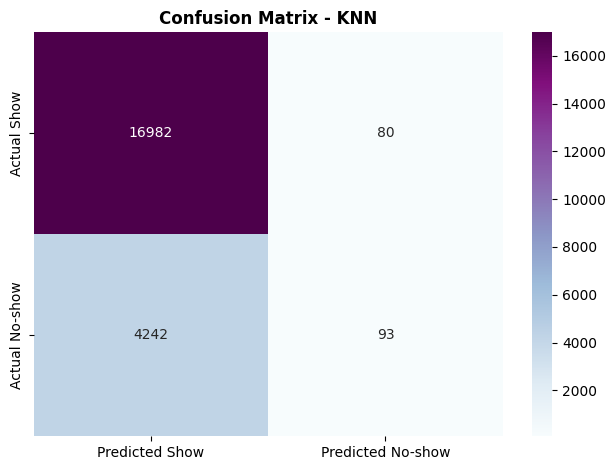

In [49]:
cm_knn = confusion_matrix(y_test, knn_pred_test)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=['Predicted Show', 'Predicted No-show'],
            yticklabels=['Actual Show', 'Actual No-show'])
plt.title('Confusion Matrix - KNN', fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
print(classification_report(y_test, knn_pred_test))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     17062
           1       0.54      0.02      0.04      4335

    accuracy                           0.80     21397
   macro avg       0.67      0.51      0.46     21397
weighted avg       0.75      0.80      0.72     21397



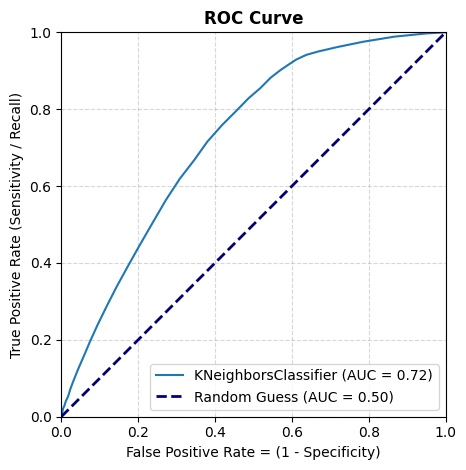

In [51]:
KNN_disp = RocCurveDisplay.from_estimator(knn, X_test_std, y_test)

# 繪製對角盲猜基準線（此時會乖乖畫在同一張圖上）
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess (AUC = 0.50)") 

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate = (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 嘗試 Threshold Tuning（門檻調校）：改用 predict_proba 手動調整預約門檻

In [52]:
## 取得「預測爽約的機率」
# predict_proba 的輸出：它會回傳一個二維的矩陣，每一筆資料都有兩個機率
# 只關心病人「會爽約（類別 1）」的機率，所以用 [:, 1]，把所有資料屬於類別 1 的機率單獨抽出來
knn_pred_test_proba = knn.predict_proba(X_test_std)[:, 1] 

In [74]:
## 定義的「警戒線」
custom_threshold = 0.2

knn_pred_custom = (knn_pred_test_proba >= custom_threshold).astype(int) # 條件判斷（產生布林值），之後做型態轉換（.astype(int)）

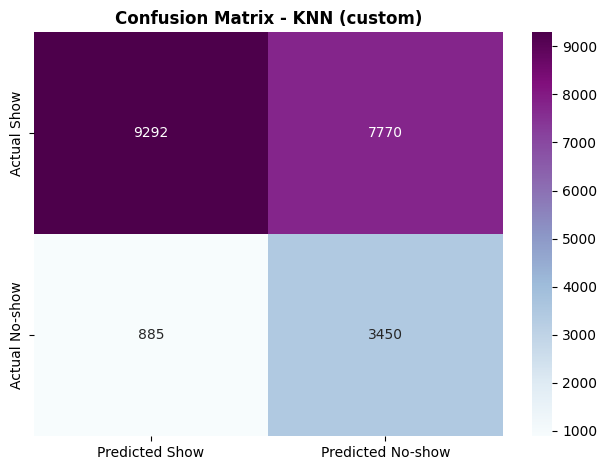

In [75]:
cm_knn_custom = confusion_matrix(y_test, knn_pred_custom)
sns.heatmap(cm_knn_custom, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=['Predicted Show', 'Predicted No-show'],
            yticklabels=['Actual Show', 'Actual No-show'])
plt.title('Confusion Matrix - KNN (custom)', fontweight='bold')
plt.tight_layout()
plt.show()

In [76]:
print(classification_report(y_test, knn_pred_custom))

              precision    recall  f1-score   support

           0       0.91      0.54      0.68     17062
           1       0.31      0.80      0.44      4335

    accuracy                           0.60     21397
   macro avg       0.61      0.67      0.56     21397
weighted avg       0.79      0.60      0.63     21397



/Users/dimplechang/miniconda3/envs/ml-env/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


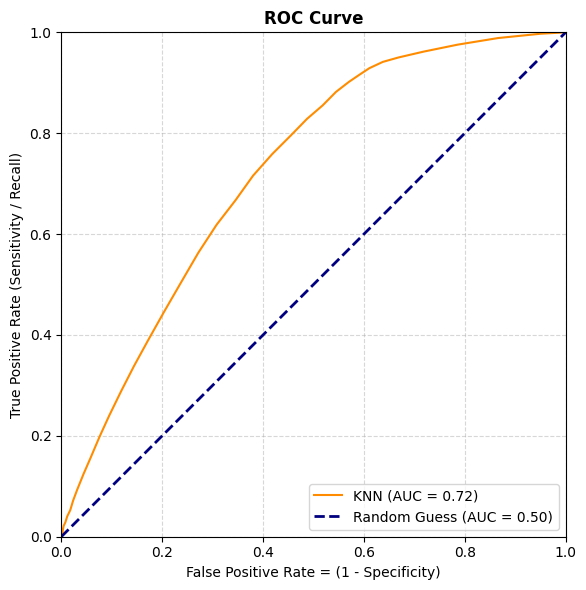

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

KNN_disp_custom = RocCurveDisplay.from_predictions(
    y_test,
    knn_pred_test_proba,
    ax=ax, 
    color="darkorange",
    name = "KNN"
)

# 繪製對角盲猜基準線（此時會乖乖畫在同一張圖上）
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess (AUC = 0.50)") 

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate = (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Decision Tree
* 不需要做特徵標準化

In [57]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(
    criterion = 'entropy',
    class_weight= "balanced",
    max_depth=3, 
    random_state=0
)
dtree.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [58]:
dtree_pred_train = dtree.predict(X_train)  
dtree_pred_test = dtree.predict(X_test)    

In [59]:
print(f"Decision Tree Train Accuracy: {accuracy_score(y_train, dtree_pred_train):.5f}")   # 訓練集
print(f"Decision Tree Test Accuracy: {accuracy_score(y_test, dtree_pred_test):.5f}")    # 訓練集

Decision Tree Train Accuracy: 0.60199
Decision Tree Test Accuracy: 0.60022


#### 視覺化

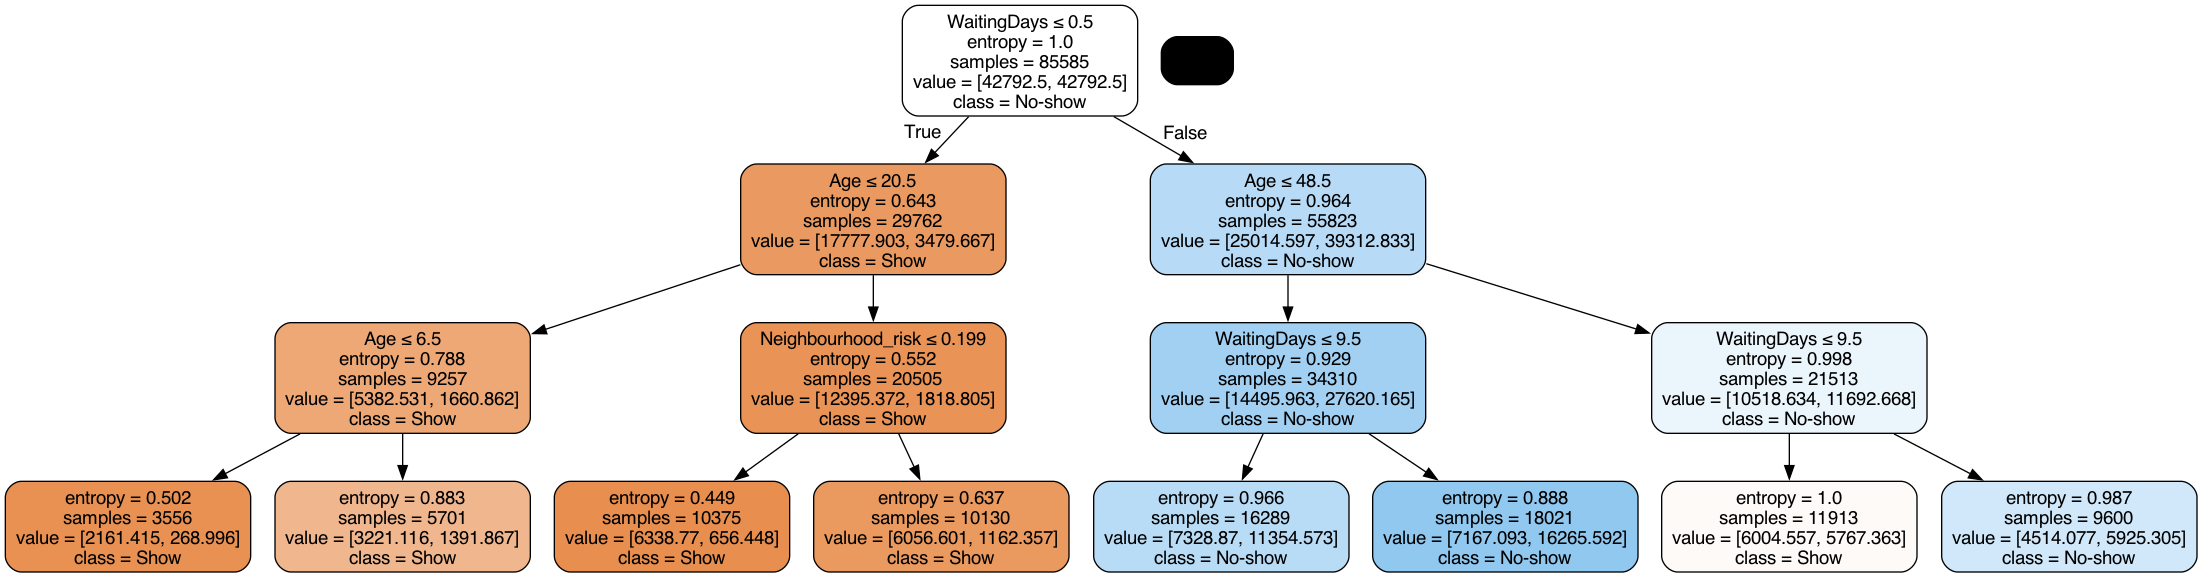

In [60]:
from sklearn.tree import export_graphviz
from sklearn import tree
import pydotplus
from IPython.display import Image  

class_labels = ['Show', 'No-show']

dot_data = tree.export_graphviz(dtree,                                 # 訓練好的決策樹模型           
                                out_file = None,                         # 不存成檔案，直接把資料存在變數 dot_data 裡  
                                feature_names = X_train.columns, # 用特徵名稱當節點標籤
                                class_names = class_labels,     # 用類別名稱當分類結果標籤
                                filled=True,                           # 會根據純度（Entropy 或 Gini）來塗色，顏色越深代表該分類越「純」
                                rounded=True,                          # 讓節點的框框變成「圓角」比較好看
                                special_characters=True                # 支援特殊字元（如 <= 符號）
                               )  

# dot_data 已經包含了圖形的資訊，但目前只是文字
# 接下來利用 pydotplus 這個套件，把 DOT 文字格式讀進去，準備轉換成圖片
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())  

In [61]:
# 看哪些特徵比較重要
dtree.feature_importances_

array([0.10887339, 0.        , 0.        , 0.        , 0.        ,
       0.88208881, 0.0090378 ])

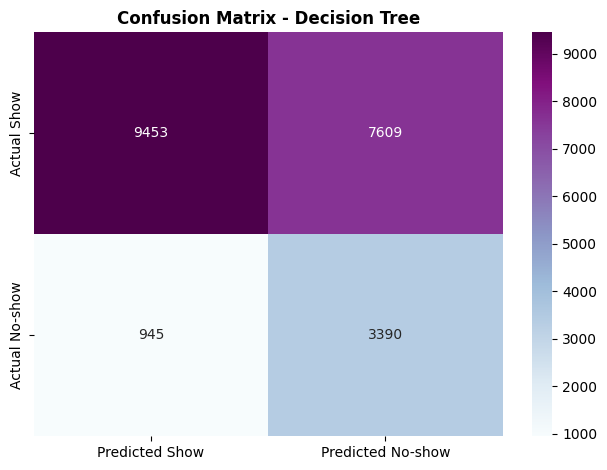

In [62]:
cm_dtree = confusion_matrix(y_test, dtree_pred_test)
sns.heatmap(cm_dtree, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=['Predicted Show', 'Predicted No-show'],
            yticklabels=['Actual Show', 'Actual No-show'])
plt.title('Confusion Matrix - Decision Tree', fontweight='bold')
plt.tight_layout()
plt.show()

In [63]:
print(classification_report(y_test, dtree_pred_test, target_names=['Show (0)', 'No-show (1)']))

              precision    recall  f1-score   support

    Show (0)       0.91      0.55      0.69     17062
 No-show (1)       0.31      0.78      0.44      4335

    accuracy                           0.60     21397
   macro avg       0.61      0.67      0.57     21397
weighted avg       0.79      0.60      0.64     21397



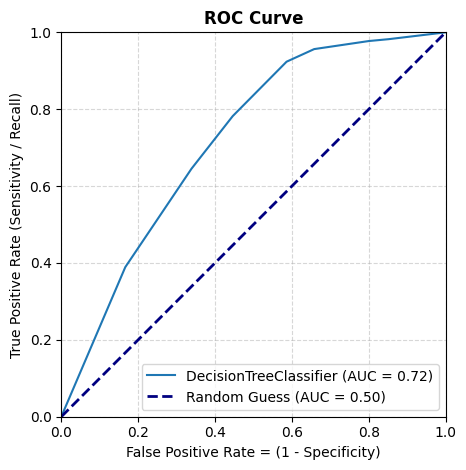

In [79]:
dtree_disp = RocCurveDisplay.from_estimator(dtree, X_test, y_test)

# 繪製對角盲猜基準線（此時會乖乖畫在同一張圖上）
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess (AUC = 0.50)") 

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate = (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Random Forest Classifier

In [64]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(criterion='entropy', 
                                n_estimators=10,      # 森林裡有幾棵樹
                                class_weight = "balanced",
                                random_state=0,
                                n_jobs=8)             # 平行運算：使用 8 個 CPU 核心，同時並行計算
forest.fit(X_train, y_train)

,n_estimators,10
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
forest_pred_train = forest.predict(X_train)  
forest_pred_test = forest.predict(X_test)  

In [66]:
print(f"Forest Train Accuracy: {accuracy_score(y_train, forest_pred_train):.5f}")   # 訓練集
print(f"Forest Test Accuracy: {accuracy_score(y_test, forest_pred_test):.5f}")    # 訓練集

Forest Train Accuracy: 0.93220
Forest Test Accuracy: 0.75025


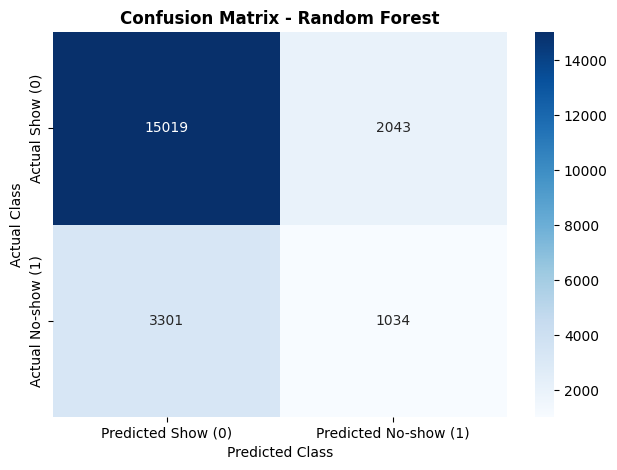

============== Classification Report =================
              precision    recall  f1-score   support

    Show (0)       0.82      0.88      0.85     17062
 No-show (1)       0.34      0.24      0.28      4335

    accuracy                           0.75     21397
   macro avg       0.58      0.56      0.56     21397
weighted avg       0.72      0.75      0.73     21397



In [67]:
# 1. 計算混淆矩陣
cm_forest = confusion_matrix(y_test, forest_pred_test)

# 2. 畫出專業的混淆矩陣熱圖
sns.heatmap(cm_forest, 
            annot=True,     # 添加註釋
            fmt='d',        # 注釋使用的格式
            cmap='Blues',   # 設定顏色
            xticklabels=['Predicted Show (0)', 'Predicted No-show (1)'],
            yticklabels=['Actual Show (0)', 'Actual No-show (1)'])
plt.title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

# 3. 印出詳細的分類報告 (包含 Precision, Recall, F1-score)
print("============== Classification Report =================")
print(classification_report(y_test, forest_pred_test, target_names=['Show (0)', 'No-show (1)']))

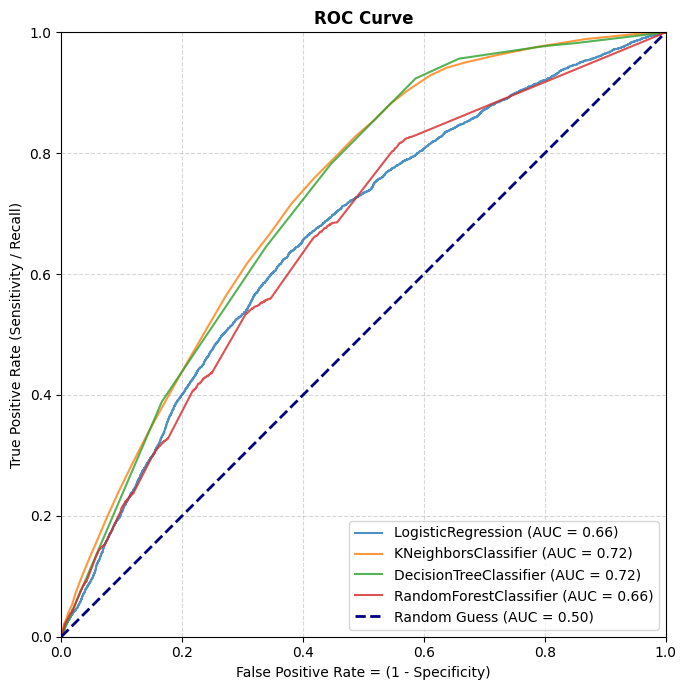

In [87]:
plt.figure(figsize=(7, 7))

# 取得目前的畫布 (Axes) 
ax = plt.gca()  # gca = get current axes

LR_disp.plot(ax=ax, curve_kwargs={'alpha': 0.8})
KNN_disp.plot(ax=ax, curve_kwargs={'alpha': 0.8})
dtree_disp.plot(ax=ax, curve_kwargs={'alpha': 0.8})

# 繪製 Random Forest 並疊加
rfc_disp = RocCurveDisplay.from_estimator(
    forest, 
    X_test, 
    y_test, 
    ax=ax, 
    curve_kwargs={'alpha': 0.8}) 

# 繪製對角盲猜基準線（此時會乖乖畫在同一張圖上）
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess (AUC = 0.50)") 

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate = (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 嘗試 Threshold Tuning（門檻調校）：改用 predict_proba 手動調整預約門檻

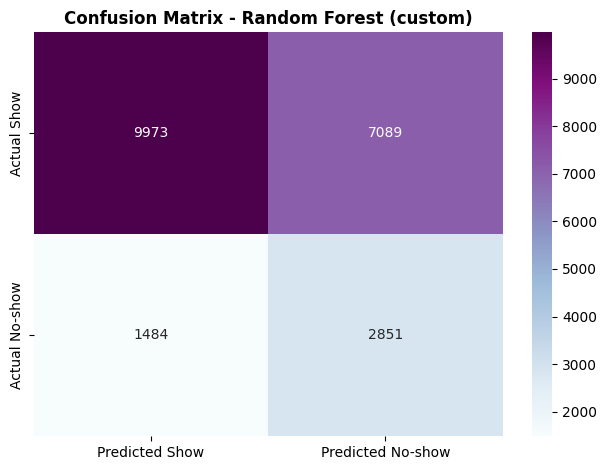

In [69]:
rfc_pred_test_proba = forest.predict_proba(X_test)[:, 1] 

custom_threshold = 0.2
rfc_pred_custom = (rfc_pred_test_proba >= custom_threshold).astype(int)

cm_rfc_custom = confusion_matrix(y_test, rfc_pred_custom)
sns.heatmap(cm_rfc_custom, annot=True, fmt='d', cmap='BuPu', 
            xticklabels=['Predicted Show', 'Predicted No-show'],
            yticklabels=['Actual Show', 'Actual No-show'])
plt.title('Confusion Matrix - Random Forest (custom)', fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
print(classification_report(y_test, rfc_pred_custom))

              precision    recall  f1-score   support

           0       0.87      0.58      0.70     17062
           1       0.29      0.66      0.40      4335

    accuracy                           0.60     21397
   macro avg       0.58      0.62      0.55     21397
weighted avg       0.75      0.60      0.64     21397

